In [50]:
import numpy as np
import matplotlib.pyplot as plt

fs = 2000              
T = 1.0                
N = int(fs * T)        
t = np.arange(N) / fs 

f1, f2, f3 = 50, 150, 450

fc = 120               

Пункт 1


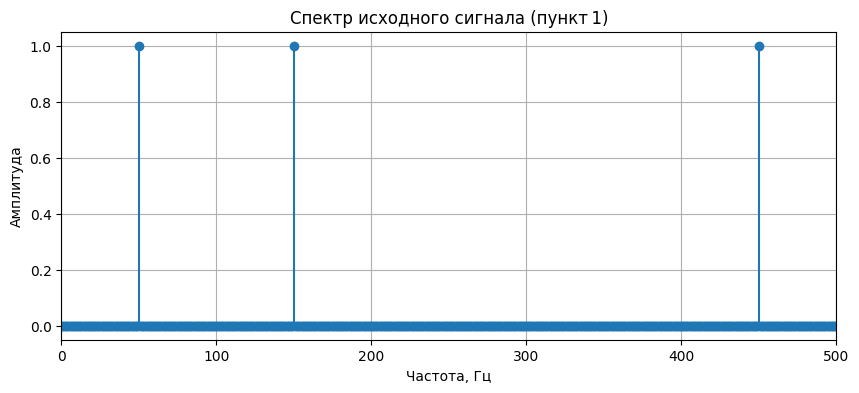

In [51]:

x = (np.cos(2 * np.pi * f1 * t) +
     np.cos(2 * np.pi * f2 * t) +
     np.cos(2 * np.pi * f3 * t))

X = np.fft.fft(x)
freq = np.fft.fftfreq(N, 1/fs)      
w = 2 * np.pi * freq                

plt.figure(figsize=(10, 4))
pos_idx = freq >= 0
plt.stem(freq[pos_idx], np.abs(X[pos_idx]) * 2 / N, basefmt=' ')
plt.xlabel('Частота, Гц')
plt.ylabel('Амплитуда')
plt.title('Спектр исходного сигнала (пункт 1)')
plt.xlim(0, 500)
plt.grid(True)
plt.show()

Пункт 2

In [52]:
wc = 2 * np.pi * fc

H = wc**2 / (-w**2 + 1j * np.sqrt(2) * wc * w + wc**2)

Y = X * H

y = np.fft.ifft(Y).real

Амплитуда исходного сигнала на частоте 50 Гц: 1.0000
Амплитуда отфильтрованного сигнала на частоте 50 Гц: 0.9853
Отношение: 0.9853


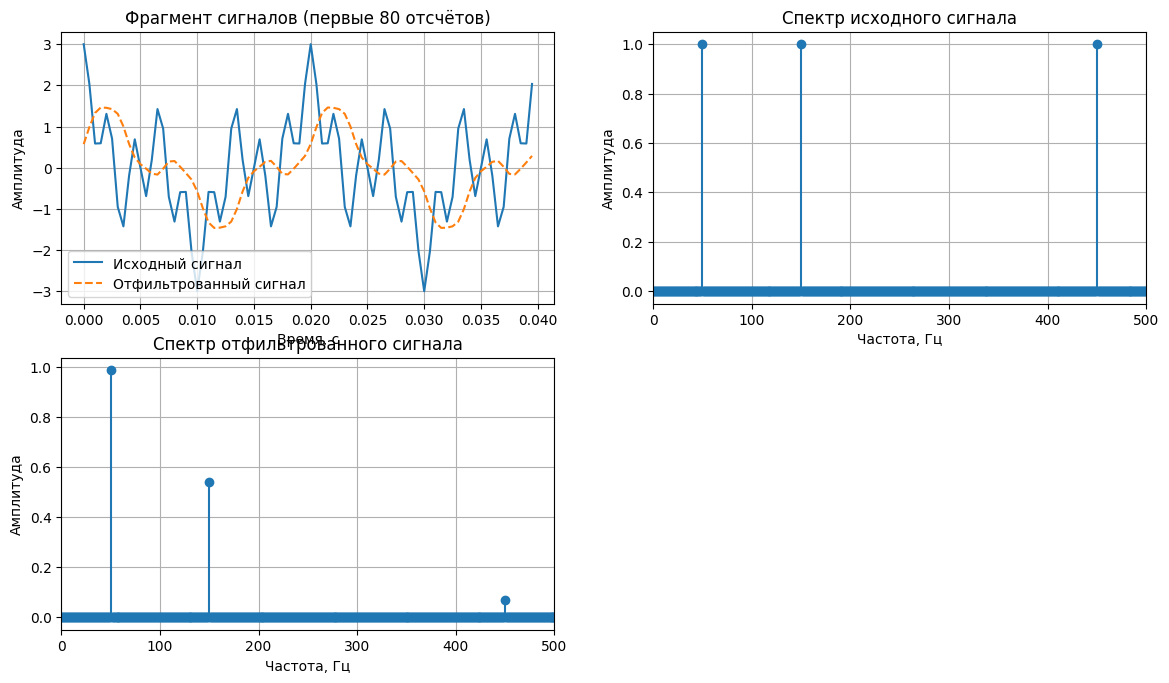

In [53]:
plt.figure(figsize=(14, 12))


plt.subplot(3, 2, 1)
plt.plot(t[:80], x[:80], label='Исходный сигнал')
plt.plot(t[:80], y[:80], '--', label='Отфильтрованный сигнал')
plt.xlabel('Время, с')
plt.ylabel('Амплитуда')
plt.title('Фрагмент сигналов (первые 80 отсчётов)')
plt.legend()
plt.grid(True)


plt.subplot(3, 2, 2)
pos_idx = freq >= 0
plt.stem(freq[pos_idx], np.abs(X[pos_idx]) * 2 / N, basefmt=' ')
plt.xlabel('Частота, Гц')
plt.ylabel('Амплитуда')
plt.title('Спектр исходного сигнала')
plt.xlim(0, 500)
plt.grid(True)


plt.subplot(3, 2, 3)
plt.stem(freq[pos_idx], np.abs(Y[pos_idx]) * 2 / N, basefmt=' ')
plt.xlabel('Частота, Гц')
plt.ylabel('Амплитуда')
plt.title('Спектр отфильтрованного сигнала')
plt.xlim(0, 500)
plt.grid(True)


idx_50 = np.argmin(np.abs(freq - 50))
A_orig = np.abs(X[idx_50]) * 2 / N
A_filt = np.abs(Y[idx_50]) * 2 / N

print(f'Амплитуда исходного сигнала на частоте 50 Гц: {A_orig:.4f}')
print(f'Амплитуда отфильтрованного сигнала на частоте 50 Гц: {A_filt:.4f}')
print(f'Отношение: {A_filt/A_orig:.4f}')

### Пункт 3: Фильтр высоких частот (ФВЧ) 2-го порядка по формуле (35)


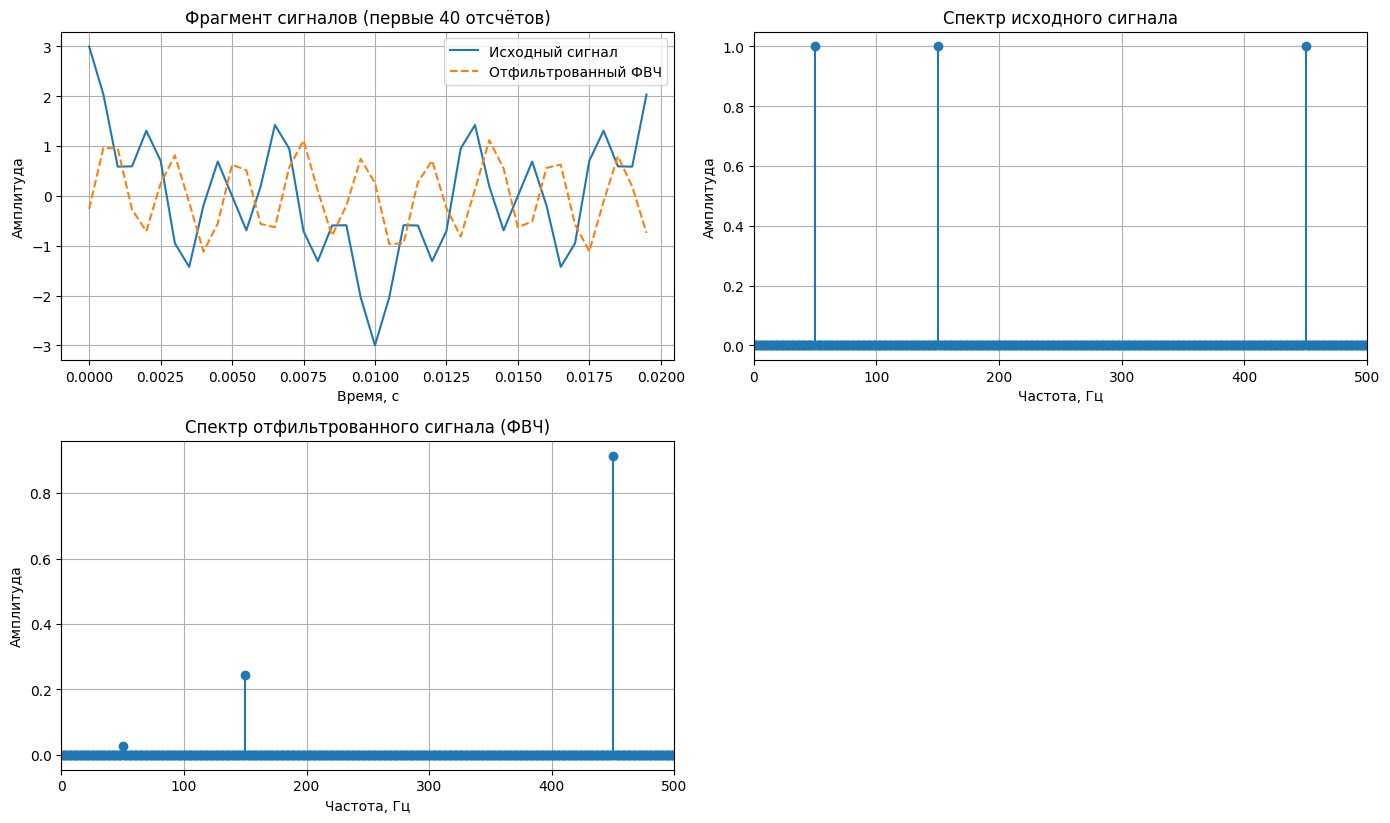

Амплитуда на 50 Гц после ФВЧ: 0.027767067240353265
Амплитуда на 150 Гц после ФВЧ: 0.2425


In [62]:


fc_high = 300  
wc_high = 2 * np.pi * fc_high

H_high = w**2 / (-w**2 + 1j * np.sqrt(2) * wc_high * w + wc_high**2)

Y_high = X * H_high
y_high = np.fft.ifft(Y_high).real

plt.figure(figsize=(14, 12))

plt.subplot(3, 2, 1)
plt.plot(t[:40], x[:40], label='Исходный сигнал')
plt.plot(t[:40], y_high[:40], '--', label='Отфильтрованный ФВЧ')
plt.xlabel('Время, с')
plt.ylabel('Амплитуда')
plt.title('Фрагмент сигналов (первые 40 отсчётов)')
plt.legend()
plt.grid(True)

plt.subplot(3, 2, 2)
plt.stem(freq[pos_idx], np.abs(X[pos_idx]) * 2 / N, basefmt=' ')
plt.xlabel('Частота, Гц')
plt.ylabel('Амплитуда')
plt.title('Спектр исходного сигнала')
plt.xlim(0, 500)
plt.grid(True)

plt.subplot(3, 2, 3)
plt.stem(freq[pos_idx], np.abs(Y_high[pos_idx]) * 2 / N, basefmt=' ')
plt.xlabel('Частота, Гц')
plt.ylabel('Амплитуда')
plt.title('Спектр отфильтрованного сигнала (ФВЧ)')
plt.xlim(0, 500)
plt.grid(True)

# Проверка
idx_50 = np.argmin(np.abs(freq - 50))
idx_150 = np.argmin(np.abs(freq - 150))
A_filt_50 = np.abs(Y_high[idx_50]) * 2 / N
A_filt_150 = np.abs(Y_high[idx_150]) * 2 / N

plt.tight_layout()
plt.show()

print(f'Амплитуда на 50 Гц после ФВЧ: {A_filt_50}')
print(f'Амплитуда на 150 Гц после ФВЧ: {A_filt_150:.4f}')

### Пункт 4: Полосовой фильтр (ПФ) и заграждающий фильтр (ЗФ)

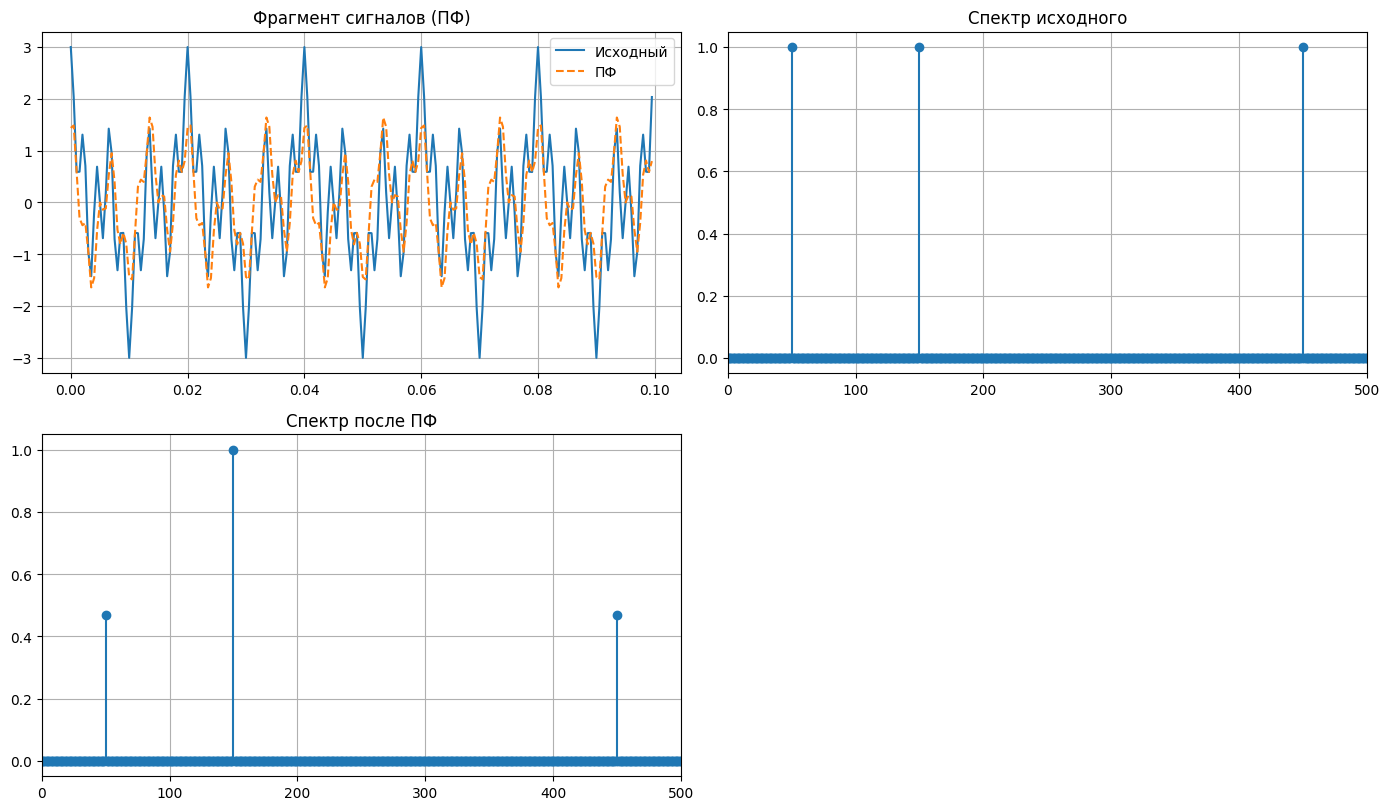

Амплитуда до фильра: 0.9999999999999991
Амплитуда после фильтра: 0.9999999999999991


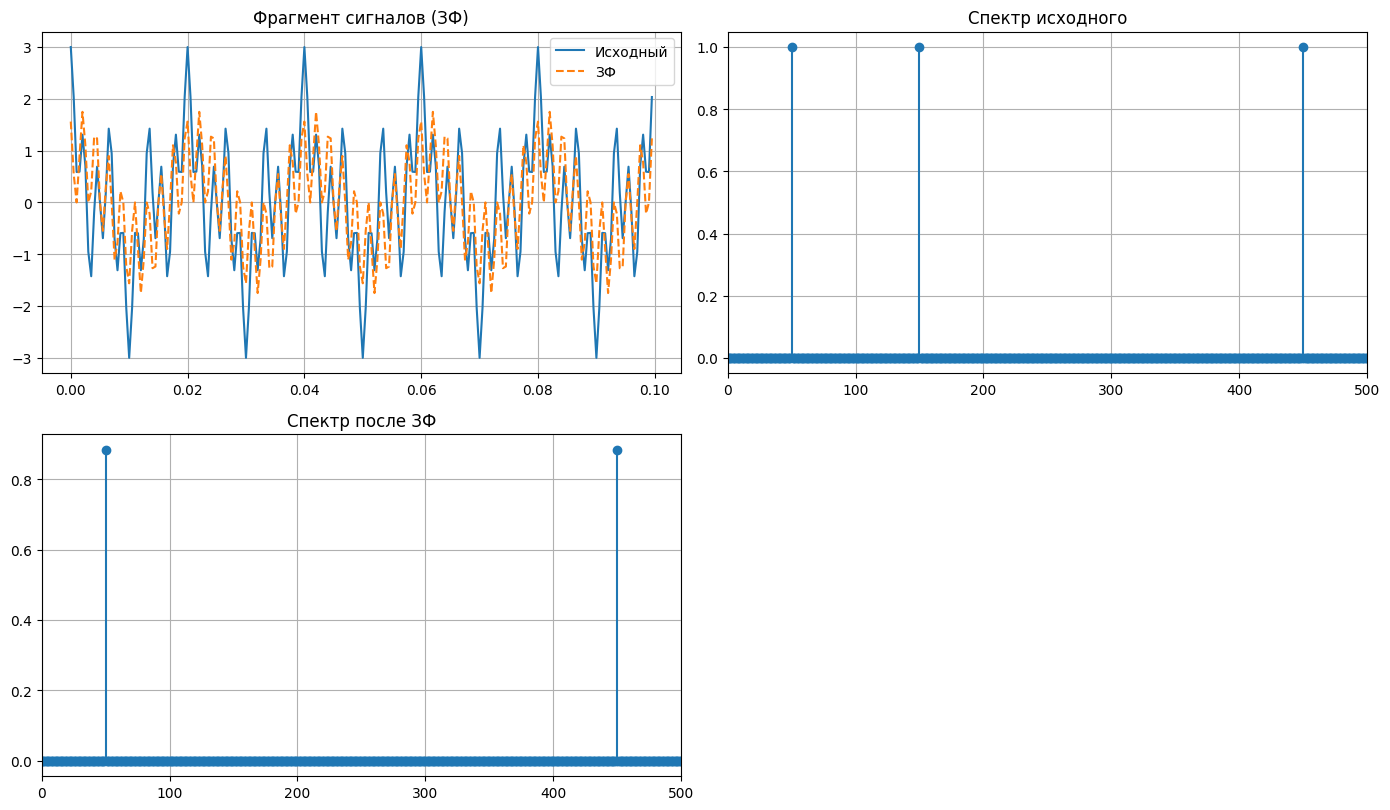

Амплитуда до фильра: 0.9999999999999991
Амплитуда после фильтра: 0.0


In [65]:


fc_band = 150
wc_band = 2 * np.pi * fc_band

# ПФ
H_band = 1j * np.sqrt(2) * wc_band * w / (-w**2 + 1j * np.sqrt(2) * wc_band * w + wc_band**2)
Y_band = X * H_band
y_band = np.fft.ifft(Y_band).real

# ЗФ
H_notch = (-w**2 + wc_band**2) / (-w**2 + 1j * np.sqrt(2) * wc_band * w + wc_band**2)
Y_notch = X * H_notch
y_notch = np.fft.ifft(Y_notch).real

# Графики для ПФ
plt.figure(figsize=(14, 12))
plt.subplot(3, 2, 1)
plt.plot(t[:200], x[:200], label='Исходный')
plt.plot(t[:200], y_band[:200], '--', label='ПФ')
plt.title('Фрагмент сигналов (ПФ)')
plt.legend()
plt.grid(True)

plt.subplot(3, 2, 2)
plt.stem(freq[pos_idx], np.abs(X[pos_idx]) * 2 / N, basefmt=' ')
plt.title('Спектр исходного')
plt.xlim(0, 500)
plt.grid(True)

plt.subplot(3, 2, 3)
plt.stem(freq[pos_idx], np.abs(Y_band[pos_idx]) * 2 / N, basefmt=' ')
plt.title('Спектр после ПФ')
plt.xlim(0, 500)
plt.grid(True)

idx_150 = np.argmin(np.abs(freq - 150))
A_orig_150 = np.abs(X[idx_150]) * 2 / N
A_band_150 = np.abs(Y_band[idx_150]) * 2 / N

plt.tight_layout()
plt.show()

print(f'Амплитуда до фильра: {A_orig_150}\nАмплитуда после фильтра: {A_band_150}')

# Графики для ЗФ
plt.figure(figsize=(14, 12))
plt.subplot(3, 2, 1)
plt.plot(t[:200], x[:200], label='Исходный')
plt.plot(t[:200], y_notch[:200], '--', label='ЗФ')
plt.title('Фрагмент сигналов (ЗФ)')
plt.legend()
plt.grid(True)

plt.subplot(3, 2, 2)
plt.stem(freq[pos_idx], np.abs(X[pos_idx]) * 2 / N, basefmt=' ')
plt.title('Спектр исходного')
plt.xlim(0, 500)
plt.grid(True)

plt.subplot(3, 2, 3)
plt.stem(freq[pos_idx], np.abs(Y_notch[pos_idx]) * 2 / N, basefmt=' ')
plt.title('Спектр после ЗФ')
plt.xlim(0, 500)
plt.grid(True)

A_notch_150 = np.abs(Y_notch[idx_150]) * 2 / N

plt.tight_layout()
plt.show()

print(f'Амплитуда до фильра: {A_orig_150}\nАмплитуда после фильтра: {A_notch_150}')

### Пункт 5: ФНЧ Баттерворта 4-го и 5-го порядка

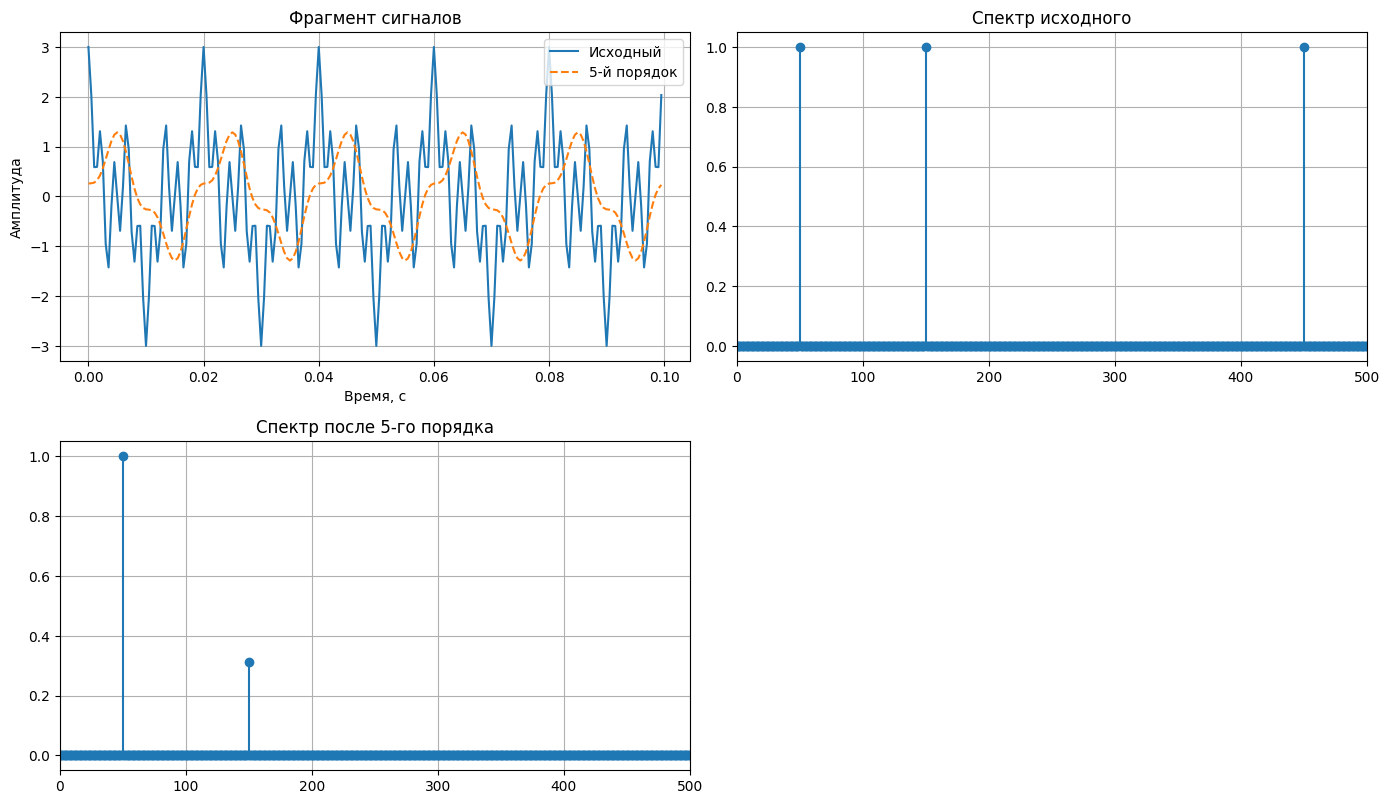

Амплитуда на 50 Гц после 5-го: 0.9999
Исходная амплитуда: 1.0000


In [75]:
def butterworth_H(w, wc, n):
    poles = []
    for k in range(1, n + 1):
        theta = np.pi / 2 + (2 * k - 1) * np.pi / (2 * n)
        poles.append(wc * (np.cos(theta) + 1j * np.sin(theta)))
   
    H = wc**n * np.ones_like(w, dtype=complex)
    for p in poles:
        H /= (1j * w - p)
   
    H /= H[0]  
    return H

# 4-й порядок 
n4 = 4
H4 = butterworth_H(w, wc, n4)
Y4 = X * H4
y4 = np.fft.ifft(Y4).real 

# 5-й порядок
n5 = 5
H5 = butterworth_H(w, wc, n5)
Y5 = X * H5
y5 = np.fft.ifft(Y5).real


plt.figure(figsize=(14, 12))

plt.subplot(3, 2, 1)
plt.plot(t[:200], x[:200], label='Исходный')
plt.plot(t[:200], y5[:200], '--', label='5-й порядок')
plt.title('Фрагмент сигналов')
plt.xlabel('Время, с')
plt.ylabel('Амплитуда')
plt.legend()
plt.grid(True)

plt.subplot(3, 2, 2)
plt.stem(freq[pos_idx], np.abs(X[pos_idx]) * 2 / N, basefmt=' ')
plt.title('Спектр исходного')
plt.xlim(0, 500)
plt.grid(True)

plt.subplot(3, 2, 3)
plt.stem(freq[pos_idx], np.abs(Y5[pos_idx]) * 2 / N, basefmt=' ')
plt.title('Спектр после 5-го порядка')  # Это повтор п.1
plt.xlim(0, 500)
plt.grid(True)

plt.tight_layout()
plt.show()

A_filt5 = np.abs(Y5[idx_50]) * 2 / N
print(f'Амплитуда на 50 Гц после 5-го: {A_filt5:.4f}\nИсходная амплитуда: {A_orig:.4f}')

### Пункт 6: Сравнение 2-го и 5-го порядка

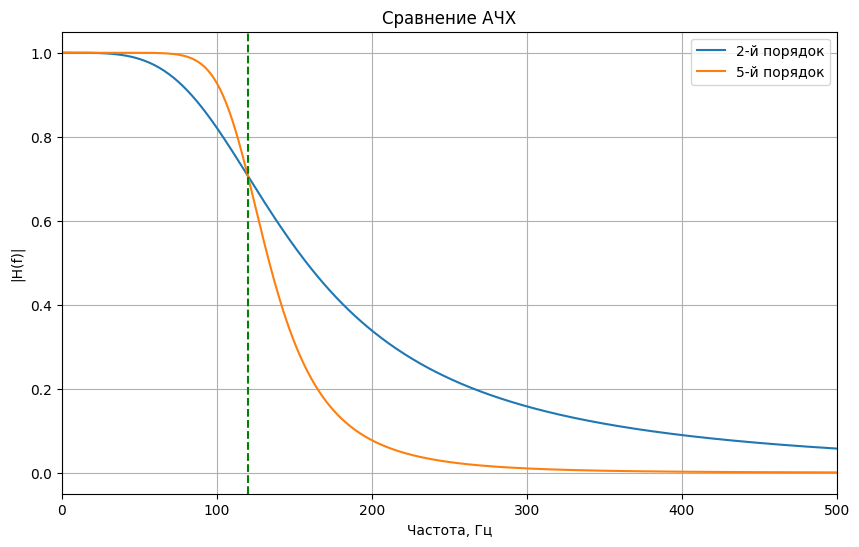

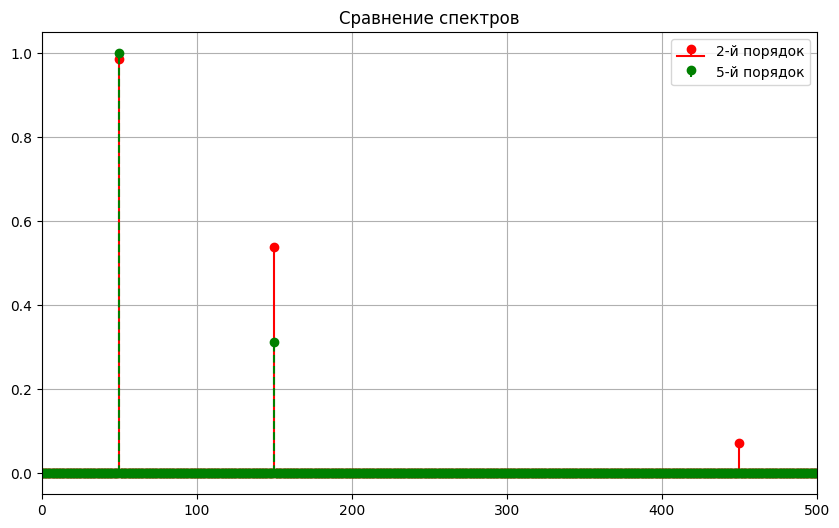

In [76]:

plt.figure(figsize=(10, 6))
plt.plot(freq[pos_idx], np.abs(H[pos_idx]), label='2-й порядок')
plt.plot(freq[pos_idx], np.abs(H5[pos_idx]), label='5-й порядок')
plt.xlabel('Частота, Гц')
plt.ylabel('|H(f)|')
plt.title('Сравнение АЧХ')
plt.xlim(0, 500)
plt.axvline(fc, color='g', ls='--')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
plt.stem(freq[pos_idx], np.abs(Y[pos_idx]) * 2 / N, label='2-й порядок', basefmt='r', linefmt = 'r')
plt.stem(freq[pos_idx], np.abs(Y5[pos_idx]) * 2 / N, label='5-й порядок', basefmt=' ', linefmt = 'g--')
plt.title('Сравнение спектров')
plt.xlim(0, 500)
plt.legend()
plt.grid(True)
plt.show()

### Пункт 7: Сравнение с scipy для 5-го порядка

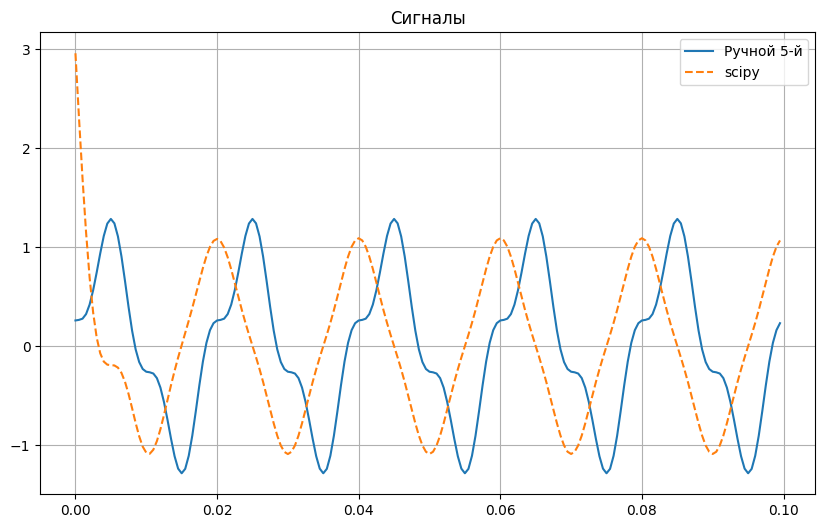

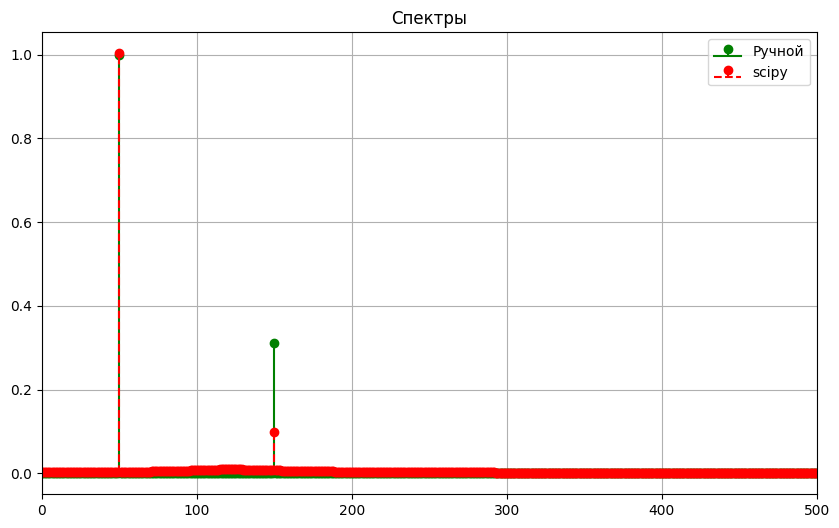

In [58]:

from scipy import signal

wn = fc / (fs / 2)
b_scipy, a_scipy = signal.butter(5, wn, 'low')
y_scipy = signal.filtfilt(b_scipy, a_scipy, x) 

Y_scipy = np.fft.fft(y_scipy)

plt.figure(figsize=(10, 6))
plt.plot(t[:200], y5[:200], label='Ручной 5-й')
plt.plot(t[:200], y_scipy[:200], '--', label='scipy')
plt.title('Сигналы')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
plt.stem(freq[pos_idx], np.abs(Y5[pos_idx]) * 2 / N, 
         linefmt='g-', markerfmt='go', label='Ручной', basefmt='g-')

plt.stem(freq[pos_idx], np.abs(Y_scipy[pos_idx]) * 2 / N, 
         linefmt='r--', markerfmt='ro', label='scipy', basefmt='r--')
plt.title('Спектры')
plt.xlim(0, 500)
plt.legend()
plt.grid(True)
plt.show()

### Пункт 8: Шум + фильтрация

[ 2.49514448  2.65039396  1.08138546  0.87938985  1.38584044  0.84730397
 -0.85911619 -1.44834703 -0.92889702  0.62390268  0.33335149 -1.43081434
 -0.12904834  0.7120643   0.57442356 -0.89839148 -2.16175964  0.01372539
 -1.48823985 -2.34170805 -3.61799961 -1.58966346 -0.51609991  0.33023913
 -1.61765103 -1.27171407  1.4013807   1.45016282 -0.15379174  0.07301419
 -0.35502018  1.15662454  0.5835815  -0.58705833 -1.72878587  0.49982804
  0.48629637  0.46857694  0.39291565  2.82523821  2.65514859  1.81069814
  0.49246714 -0.20929038  1.24443047  0.7919056  -0.58136922 -2.07714587
 -0.06566894 -0.20670094 -0.03666151 -0.61760235 -0.06944825  1.83324156
  0.76046431 -1.01675194 -0.4710781  -0.59579929 -0.24881486 -2.58770222
 -3.49361066 -2.05940778 -0.2805579  -0.660642   -0.51004491 -0.99493114
  0.28913391  1.4573819   0.34388682 -0.26191147 -0.32527265  0.93276311
 -0.5633344  -1.22813327 -1.81190863  0.28294587  1.20215695  0.60846868
  0.78228762  1.07181738  2.94209573  2.23014894  0

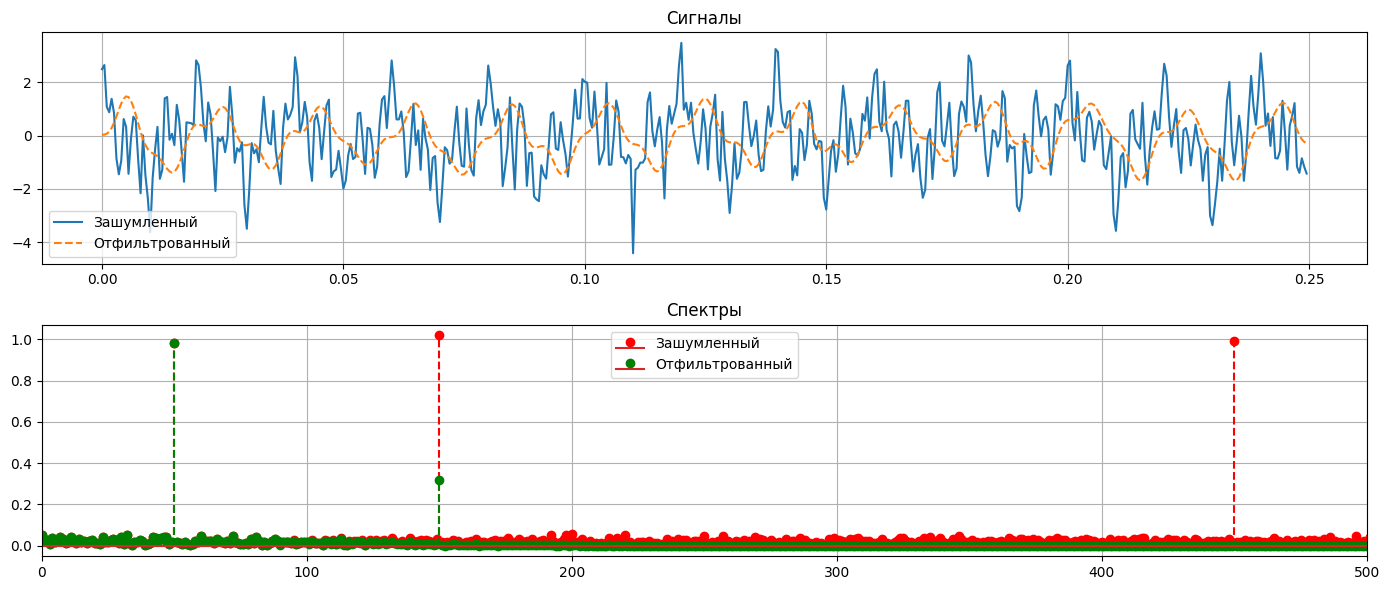

In [59]:

noise = np.random.normal(0, 0.5, N)
x_noisy = x + noise
X_noisy = np.fft.fft(x_noisy)

Y_noisy = X_noisy * H5
y_noisy_filt = np.fft.ifft(Y_noisy).real

print(x_noisy[:100])

plt.figure(figsize=(14, 6))
plt.subplot(2, 1, 1)
plt.plot(t[:500], x_noisy[:500], label='Зашумленный')
plt.plot(t[:500], y_noisy_filt[:500], '--', label='Отфильтрованный')
plt.title('Сигналы')
plt.legend()
plt.grid(True)

plt.subplot(2, 1, 2)
plt.stem(freq[pos_idx], np.abs(X_noisy[pos_idx]) * 2 / N, label='Зашумленный', linefmt='r--')
plt.stem(freq[pos_idx], np.abs(Y_noisy[pos_idx]) * 2 / N, label='Отфильтрованный', linefmt='g--')
plt.title('Спектры')
plt.xlim(0, 500)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Пункт 9: ФНЧ Чебышева 1-го рода N=5

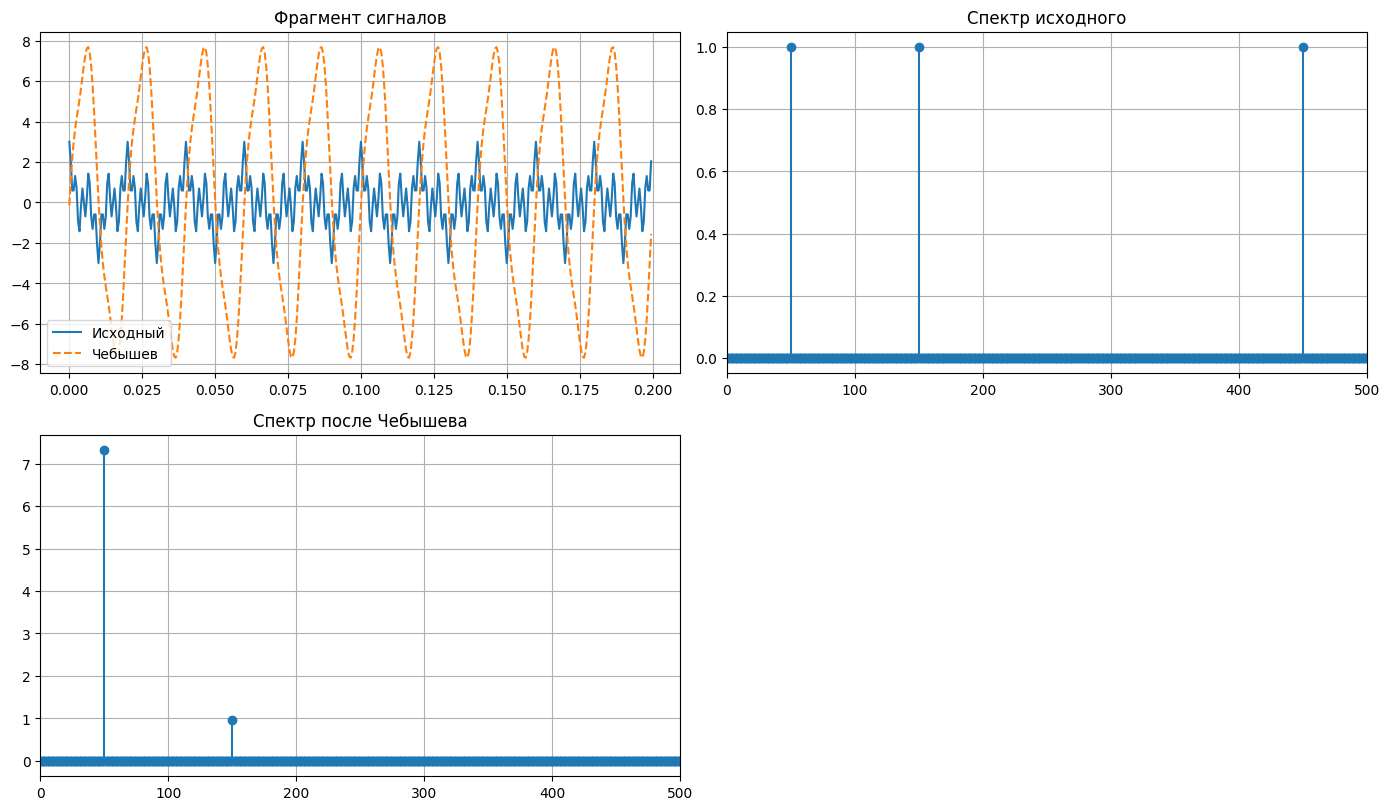

In [77]:

def chebyshev1_H(w, wc, n, ripple_db=1):
    epsilon = np.sqrt(10**(ripple_db / 10) - 1)
    mu = (1 / n) * np.arcsinh(1 / epsilon)
    
    poles = []
    for k in range(1, n + 1):
        phi = (2 * k - 1) * np.pi / (2 * n)
        sigma = -np.sinh(mu) * np.sin(phi)
        omega = np.cosh(mu) * np.cos(phi)
        poles.append(wc * (sigma + 1j * omega))
    
    H = wc**n * np.ones_like(w, dtype=complex)
    for p in poles:
        H /= (1j * w - p)
    
    
    if n % 2 == 0:
        H /= np.sqrt(1 + epsilon**2)
    else:
        H /= (1 + epsilon**2)**(1/(2*n))
    
    return H

H_cheb = chebyshev1_H(w, wc, 5, ripple_db=1)
Y_cheb = X * H_cheb
y_cheb = np.fft.ifft(Y_cheb).real


plt.figure(figsize=(14, 12))
plt.subplot(3, 2, 1)
plt.plot(t[:400], x[:400], label='Исходный')
plt.plot(t[:400], y_cheb[:400], '--', label='Чебышев')
plt.title('Фрагмент сигналов')
plt.legend()
plt.grid(True)

plt.subplot(3, 2, 2)
plt.stem(freq[pos_idx], np.abs(X[pos_idx]) * 2 / N, basefmt=' ')
plt.title('Спектр исходного')
plt.xlim(0, 500)
plt.grid(True)

plt.subplot(3, 2, 3)
plt.stem(freq[pos_idx], np.abs(Y_cheb[pos_idx]) * 2 / N, basefmt=' ')
plt.title('Спектр после Чебышева')
plt.xlim(0, 500)
plt.grid(True)

A_cheb = np.abs(Y_cheb[idx_50]) * 2 / N

plt.tight_layout()
plt.show()